# 新入职的员工的背景资料分析

In [758]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']
%matplotlib inline
import pyecharts.options as opts
from pyecharts.charts import Line
from pyecharts.commons.utils import JsCode
from pyecharts.faker import Collector, Faker
from pyecharts.globals import ThemeType

In [355]:
this_year = pd.read_csv('Background2019.csv')
last_year = pd.read_csv('Background2018.csv')
this_year['label'] = 2019
last_year['label'] = 2018
this_year = this_year[['营业区','年龄','年龄区间','学历','性别','籍贯','婚姻状态','是否有小孩','在深居住时间','加盟新华前从事的职业', '同业从业时间', '同业职级', '加盟新华前年收入','加盟前是否购买过保险产品','label']]
this_year.columns = ['district', 'age', 'age_range','education','gender','hometown','marriage','kids','residency_time','occupation','same_job_duration','same_job_rank','income','insurrance','label']
this_year.sample

last_year = last_year[['营业区','年龄','年龄区间','学历','性别','籍贯','婚姻状态','是否有小孩','在深居住时间','加盟新华前从事的职业', '同业从业时间', '同业职级', '加盟新华前年收入','加盟前是否购买过保险产品','label']]
last_year.columns = ['district', 'age', 'age_range','education','gender','hometown','marriage','kids','residency_time','occupation','same_job_duration','same_job_rank','income','insurrance','label']
last_year.sample

# last_year['age'].fillna(last_year['age'].mean(), inplace = True)
# this_year['age'].fillna(this_year['age'].mean(), inplace = True)
# 合并数据框
all_data = [this_year, last_year]
all_data = pd.concat(all_data)



查看数据结构

In [356]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1676 entries, 0 to 485
Data columns (total 15 columns):
district             1676 non-null object
age                  1674 non-null float64
age_range            1674 non-null object
education            1674 non-null object
gender               1676 non-null object
hometown             1673 non-null object
marriage             1676 non-null object
kids                 1676 non-null object
residency_time       1675 non-null object
occupation           1676 non-null object
same_job_duration    611 non-null object
same_job_rank        610 non-null object
income               1676 non-null object
insurrance           1670 non-null object
label                1676 non-null int64
dtypes: float64(1), int64(1), object(13)
memory usage: 209.5+ KB


In [357]:
all_data.head()

,district,age,age_range,education,gender,hometown,marriage,kids,residency_time,occupation,same_job_duration,same_job_rank,income,insurrance,label
0,宝安,23.0,不足25岁,高中,女,云南,未婚,否,3-5年,行政办公人员,NaN,NaN,10万以内,否,2019
1,宝安,30.0,25-30岁,高中,男,广东,已婚,是,5年以上,个体经营者,NaN,NaN,10万以内,是,2019
2,宝安,48.0,45岁以上,高中,女,湖南,已婚,是,5年以上,个体经营者,NaN,NaN,10万以内,是,2019
3,龙岗,41.0,31-45岁,高中,男,江西,已婚,是,5年以上,个体经营者,NaN,NaN,10万以内,是,2019
4,龙华,37.0,31-45岁,高中,女,广西,已婚,是,1年内,同业销售,1-3年,营销员,10万以内,是,2019


## 查看新增员工的同比增长率

In [358]:
# 2018-2019不同营业区男性和女性的比重的同比变化
this_year_ratio_female = all_data[(all_data['gender'] == '女') &(all_data['label'] == 2019)].gender.count()/all_data[all_data['label'] == 2019].gender.count()
last_year_ratio_female = all_data[(all_data['gender'] == '女') &(all_data['label'] == 2018)].gender.count()/all_data[all_data['label'] == 2018].gender.count()
this_year_ratio_male = 1 - this_year_ratio_female
last_year_ratio_male = 1 - last_year_ratio_female
# 同比去年女性新职工比重增加比例
print((this_year_ratio_female - last_year_ratio_female)/last_year_ratio_female)
# 同比去年男性职工比重增加比例
print((this_year_ratio_male - last_year_ratio_male)/last_year_ratio_male)

-0.06481549141395683
0.08518607442977183


按区域查看新增员工的比重同比增长率

In [359]:
# 2019年女性新职工比例(分区域)
temp1 = all_data[(all_data['gender'] == '女') &(all_data['label'] == 2019)].groupby('district').gender.count()/all_data[all_data['label'] == 2019].groupby('district').gender.count()
print(temp1)
# 2019年男性新职工比例(分区域)
print('-----------------')
temp2 = all_data[(all_data['gender'] == '男') &(all_data['label'] == 2019)].groupby('district').gender.count()/all_data[all_data['label'] == 2019].groupby('district').gender.count()
print(temp2)
# 2018年女性新职工比例(分区域)
print('-----------------')
temp3 = all_data[(all_data['gender'] == '女') &(all_data['label'] == 2018)].groupby('district').gender.count()/all_data[all_data['label'] == 2018].groupby('district').gender.count()
print(temp3)
# 2018年男性新职工比例(分区域)
print('-----------------')
temp4 = all_data[(all_data['gender'] == '男') &(all_data['label'] == 2018)].groupby('district').gender.count()/all_data[all_data['label'] == 2018].groupby('district').gender.count()
print(temp4)

# 2018至2019各地区女性职工比例的同比变化率
print('-----------------')
print((temp1-temp3)/temp3)

# 2018至2019各地区男性职工比例的同比变化率
print('-----------------')
print((temp2-temp4)/temp4)

district
中心区    0.477612
卓越区    0.641026
宝安     0.579661
横岗     0.515464
沙井     0.518248
龙华     0.481928
龙岗     0.607477
Name: gender, dtype: float64
-----------------
district
中心区    0.522388
卓越区    0.358974
宝安     0.420339
横岗     0.484536
沙井     0.481752
龙华     0.518072
龙岗     0.392523
Name: gender, dtype: float64
-----------------
district
中心区    0.618705
卓越区    0.562500
宝安     0.547368
横岗     0.575000
沙井     0.711538
龙华     0.575758
龙岗     0.450450
Name: gender, dtype: float64
-----------------
district
中心区    0.381295
卓越区    0.437500
宝安     0.452632
横岗     0.425000
沙井     0.288462
龙华     0.424242
龙岗     0.549550
Name: gender, dtype: float64
-----------------
district
中心区   -0.228046
卓越区    0.139601
宝安     0.058996
横岗    -0.103541
沙井    -0.271651
龙华    -0.162968
龙岗     0.348598
Name: gender, dtype: float64
-----------------
district
中心区    0.370037
卓越区   -0.179487
宝安    -0.071344
横岗     0.140085
沙井     0.670073
龙华     0.221170
龙岗    -0.285736
Name: gender, dtype: float64


## 查看新入职员工的年龄分布

D:\Anaconda\lib\site-packages\ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':
D:\Anaconda\lib\site-packages\ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del sys.path[0]


Text(0.5, 1.0, '2019年新入职男员工年龄分布')

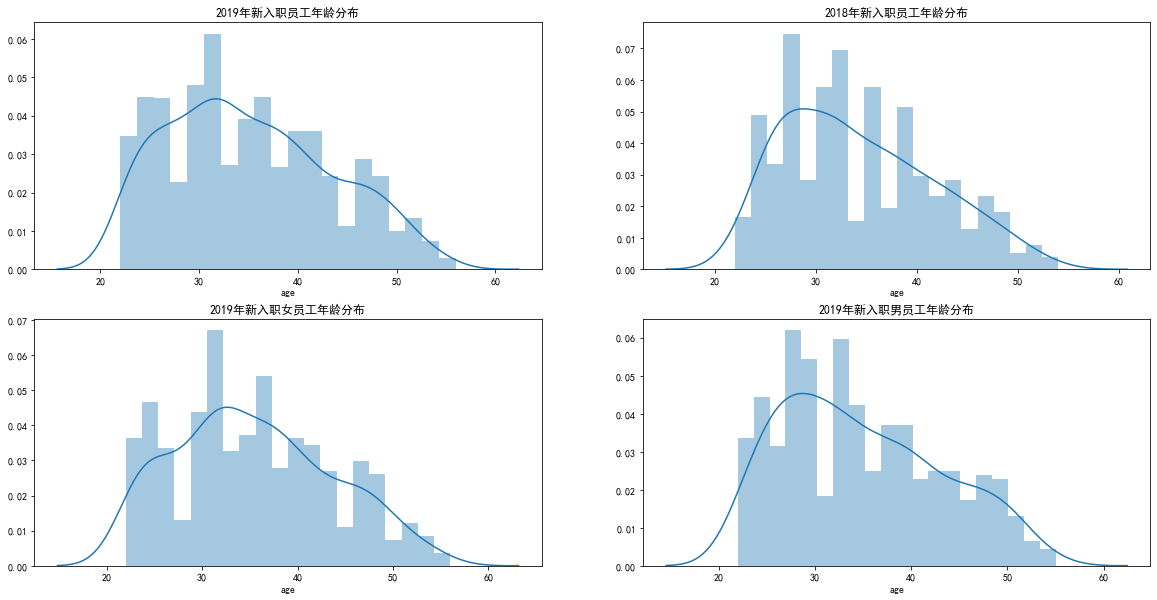

In [438]:
# fig, (ax1,ax2) = plt.subplots(2,2, figsize = (10,10))
# sns.distplot(all_data[all_data['label']==2019].age, ax = ax1)
# plt.title('2019年所有新入职员工的年龄分布', fontsize = 14, ax = ax1)
# sns.distplot(all_data.loc[all_data['label']==2018,'age'], ax = ax2)
# plt.title('2018年所有新入职员工的年龄分布', fontsize = 14, ax = ax2)
# sns.distplot(all_data.loc[(all_data['label']==2019) & (all_data['gender']=='男'),'age'], ax = ax3)
# plt.title('2019年所有新入职员工的年龄分布', fontsize = 14, ax = ax3)
# sns.distplot(all_data.loc[(all_data['label']==2019) & (all_data['gender']=='女'),'age'], ax = ax4)
# plt.title('2019年所有新入职员工的年龄分布', fontsize = 14, ax = ax4)

# 填充缺失项
all_data['age'][41] = all_data['age'].mean()
all_data['age'][62] = all_data['age'].mean()
all_data['age'].isna()

# 分布
fig, axes = plt.subplots(2,2,figsize = (20,10))
sns.distplot(all_data.loc[all_data['label'] == 2019,'age'], bins = 20, ax = axes[0,0] )
axes[0,0].set_title('2019年新入职员工年龄分布')
sns.distplot(all_data.loc[all_data['label'] == 2018,'age'], bins = 20, ax = axes[0,1])
axes[0,1].set_title('2018年新入职员工年龄分布')
sns.distplot(all_data.loc[(all_data['label'] == 2019) & (all_data['gender'] == '女'),'age'], bins = 20, ax = axes[1,0])
axes[1,0].set_title('2019年新入职女员工年龄分布')
sns.distplot(all_data.loc[(all_data['label'] == 2019) & (all_data['gender'] == '男'),'age'], bins = 20, ax = axes[1,1])
axes[1,1].set_title('2019年新入职男员工年龄分布')

Text(0, 0.5, '数量')

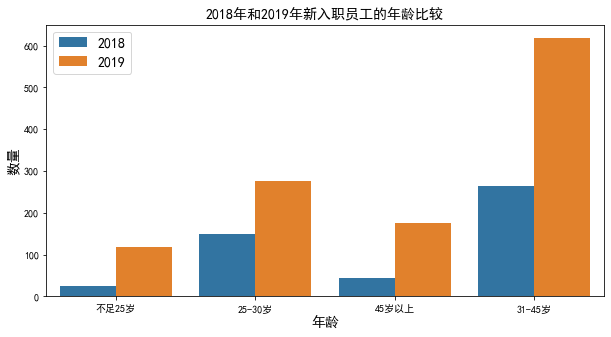

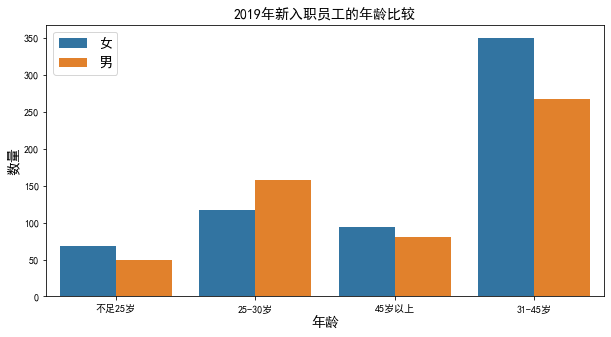

In [546]:
# 柱状图
plt.figure(figsize=(10,5))
sns.countplot(x = 'age_range', hue = 'label', data = all_data)
plt.legend(fontsize = 14)
plt.title('2018年和2019年新入职员工的年龄比较',fontsize= 14)
plt.xlabel('年龄',fontsize = 14)
plt.ylabel('数量',fontsize = 14)

plt.figure(figsize=(10,5))
sns.countplot(x = 'age_range', hue = 'gender', data = all_data[all_data['label'] == 2019])
plt.legend(fontsize = 14)
plt.title('2019年新入职员工的年龄比较',fontsize= 14)
plt.xlabel('年龄',fontsize = 14)
plt.ylabel('数量',fontsize = 14)


(array([10., 20., 30., 40., 50., 60., 70.]),
 <a list of 7 Text yticklabel objects>)

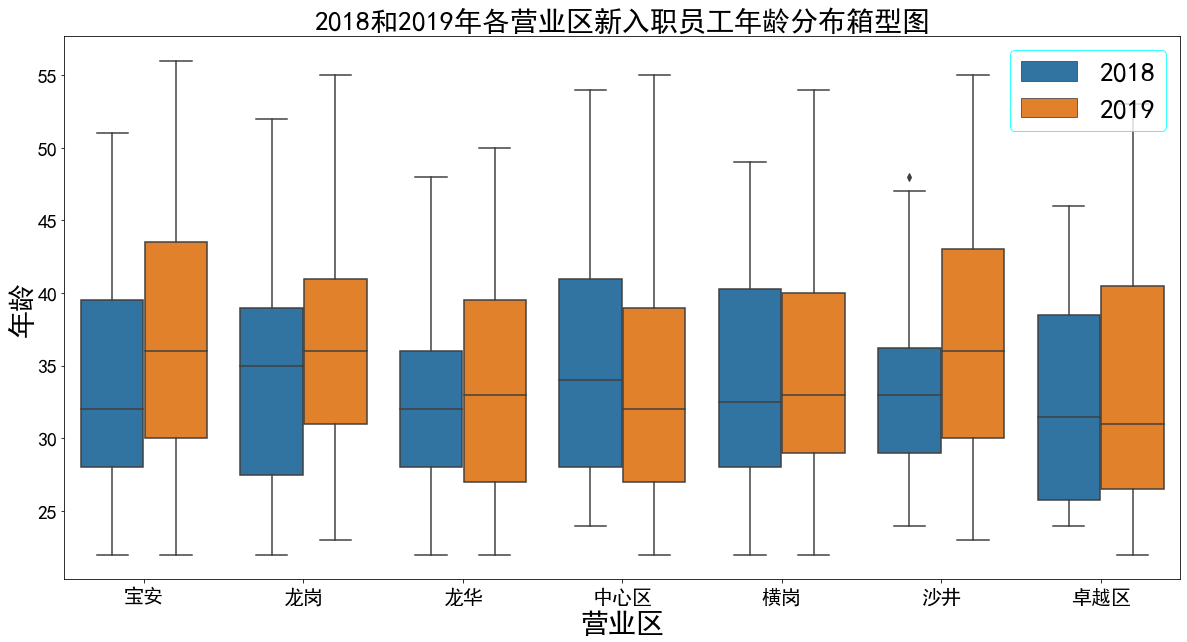

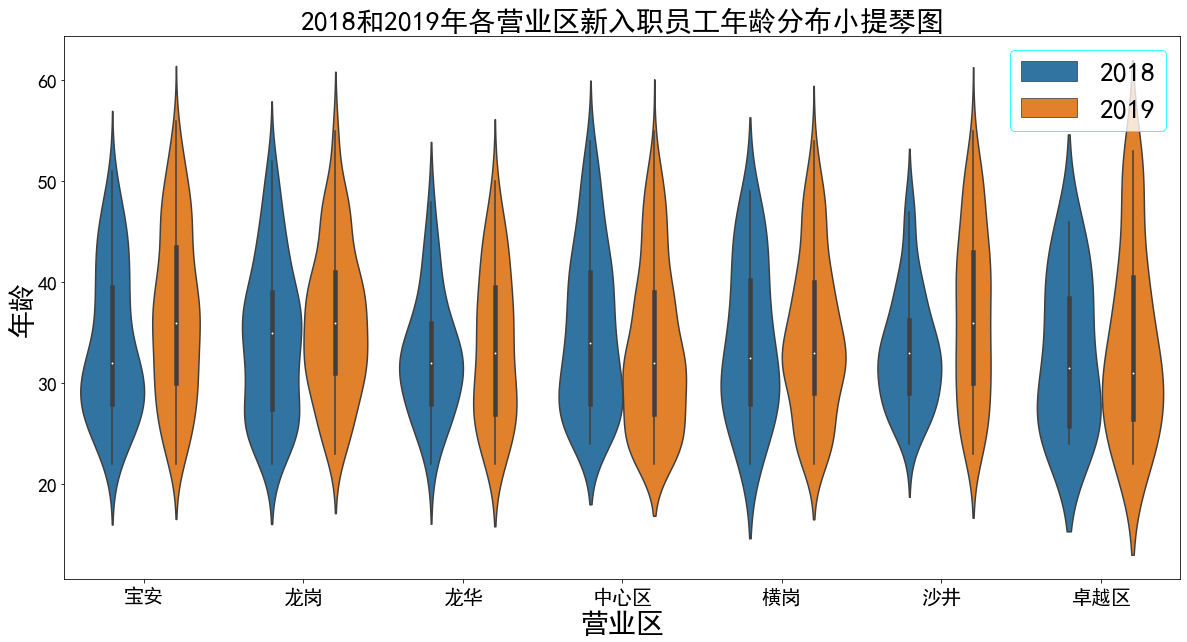

In [280]:
# plt.figure(figsize = (10,5))
# sns.boxplot(x = 'district', y = 'age', data = all_data[all_data['label'] == 2019])
# plt.title('2019年各营业区新入职员工年龄分布箱型图', fontsize = 14)
# plt.xlabel('营业区' , fontsize = 14)
# plt.ylabel('年龄', fontsize = 14)

# plt.figure(figsize = (10,5))
# sns.boxplot(x = 'district', y = 'age', data = all_data[all_data['label'] == 2018])
# plt.title('2018年各营业区新入职员工年龄分布箱型图', fontsize = 14)
# plt.xlabel('营业区' , fontsize = 14)
# plt.ylabel('年龄', fontsize = 14)

# 箱型图
plt.figure(figsize = (20,10))
sns.boxplot(x = 'district', y = 'age', hue = 'label', data = all_data)
plt.legend(loc = 'upper right', fontsize = 28, frameon = True, edgecolor = 'aqua')
plt.title('2018和2019年各营业区新入职员工年龄分布箱型图', fontsize = 28)
plt.xlabel('营业区' , fontsize = 28)
plt.ylabel('年龄', fontsize = 28)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)

# 小提琴图
plt.figure(figsize = (20,10))
sns.violinplot(x = 'district', y = 'age', hue = 'label', data = all_data)
plt.legend(loc = 'upper right', fontsize = 28, frameon = True, edgecolor = 'aqua')
plt.title('2018和2019年各营业区新入职员工年龄分布小提琴图', fontsize = 28)
plt.xlabel('营业区' , fontsize = 28)
plt.ylabel('年龄', fontsize = 28)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)

(array([10., 20., 30., 40., 50., 60., 70.]),
 <a list of 7 Text yticklabel objects>)

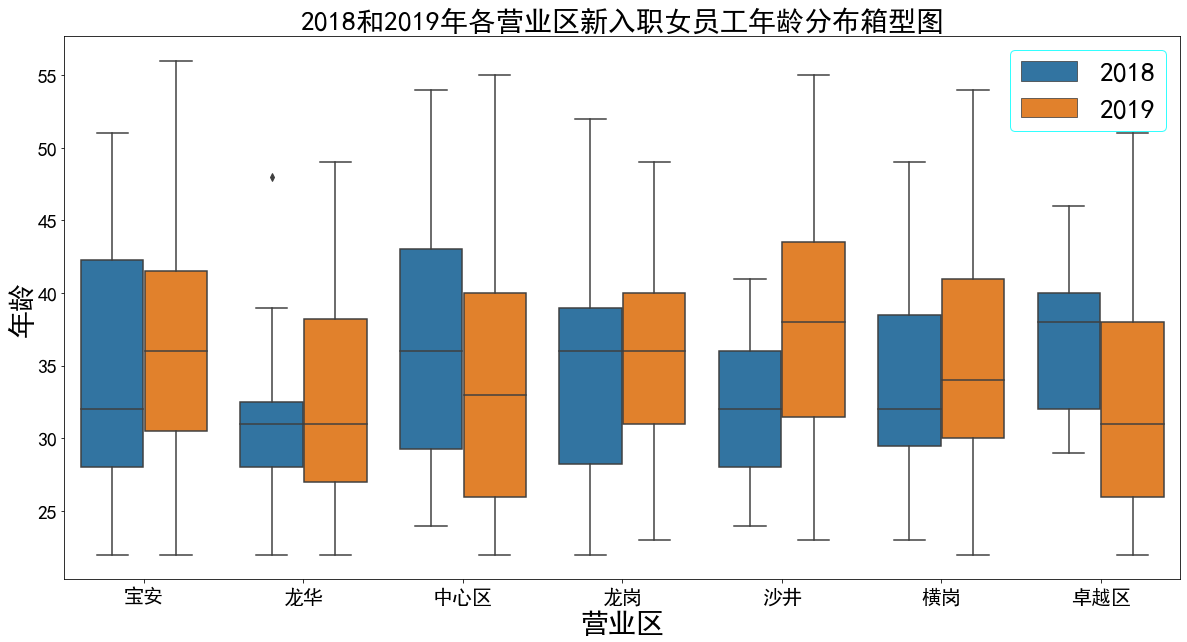

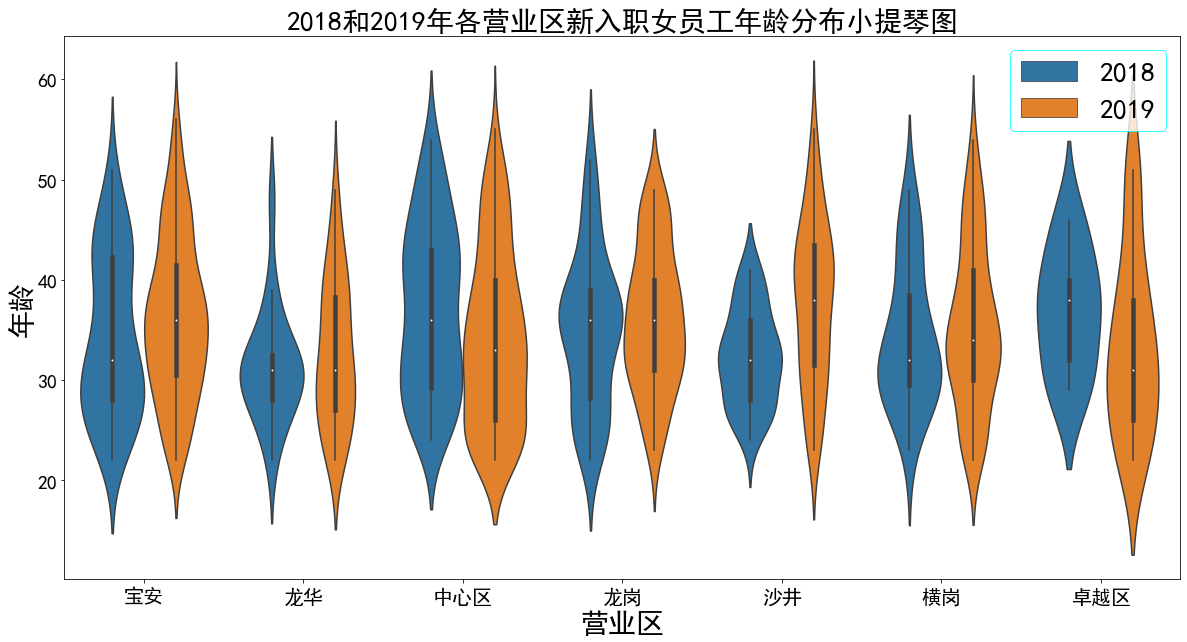

In [281]:
# 箱型图
plt.figure(figsize = (20,10))
sns.boxplot(x = 'district', y = 'age', hue = 'label', data = all_data[all_data['gender']=='女'])
plt.legend(loc = 'upper right', fontsize = 28, frameon = True, edgecolor = 'aqua')
plt.title('2018和2019年各营业区新入职女员工年龄分布箱型图', fontsize = 28)
plt.xlabel('营业区' , fontsize = 28)
plt.ylabel('年龄', fontsize = 28)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)

# 小提琴图
plt.figure(figsize = (20,10))
sns.violinplot(x = 'district', y = 'age', hue = 'label', data = all_data[all_data['gender']=='女'])
plt.legend(loc = 'upper right', fontsize = 28, frameon = True, edgecolor = 'aqua')
plt.title('2018和2019年各营业区新入职女员工年龄分布小提琴图', fontsize = 28)
plt.xlabel('营业区' , fontsize = 28)
plt.ylabel('年龄', fontsize = 28)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)

(array([ 0., 10., 20., 30., 40., 50., 60., 70.]),
 <a list of 8 Text yticklabel objects>)

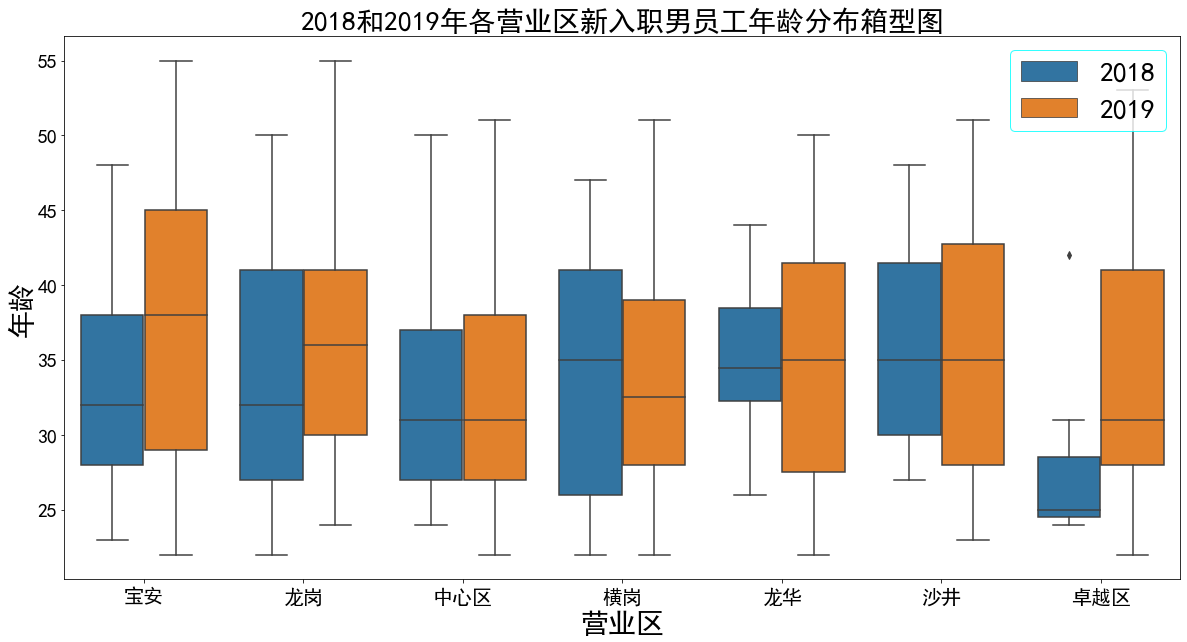

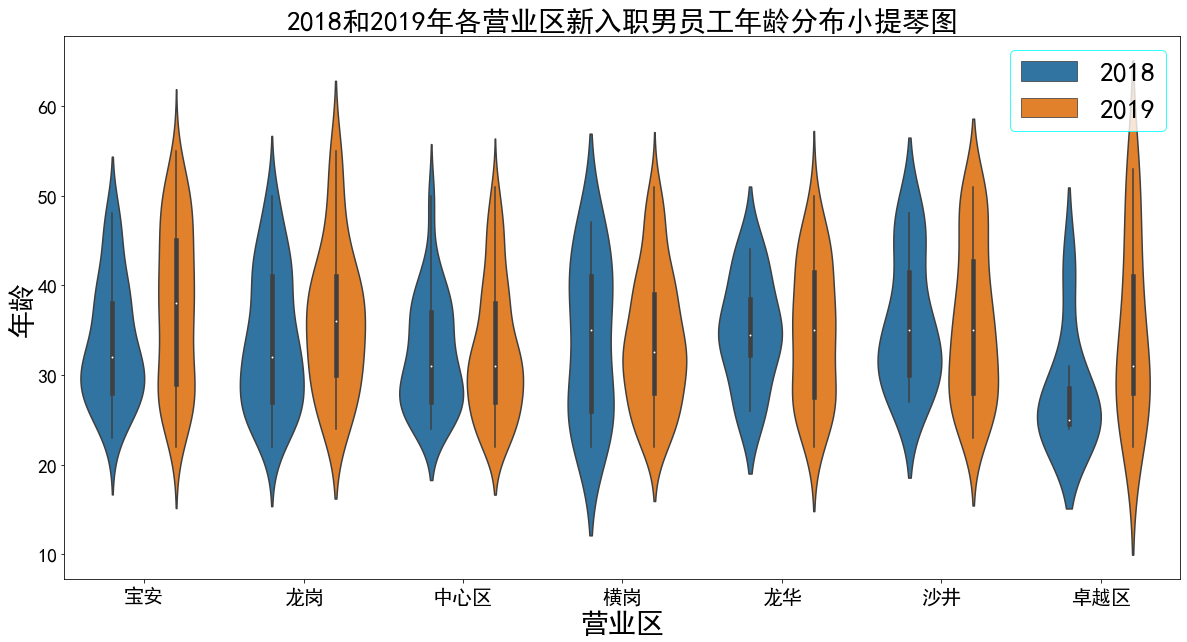

In [282]:
# 箱型图
plt.figure(figsize = (20,10))
sns.boxplot(x = 'district', y = 'age', hue = 'label', data = all_data[all_data['gender']=='男'])
plt.legend(loc = 'upper right', fontsize = 28, frameon = True, edgecolor = 'aqua')
plt.title('2018和2019年各营业区新入职男员工年龄分布箱型图', fontsize = 28)
plt.xlabel('营业区' , fontsize = 28)
plt.ylabel('年龄', fontsize = 28)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)

# 小提琴图
plt.figure(figsize = (20,10))
sns.violinplot(x = 'district', y = 'age', hue = 'label', data = all_data[all_data['gender']=='男'])
plt.legend(loc = 'upper right', fontsize = 28, frameon = True, edgecolor = 'aqua')
plt.title('2018和2019年各营业区新入职男员工年龄分布小提琴图', fontsize = 28)
plt.xlabel('营业区' , fontsize = 28)
plt.ylabel('年龄', fontsize = 28)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)

Text(0.5, 1.0, '2019年男性和女性新入职人员任职前职业类型对比')

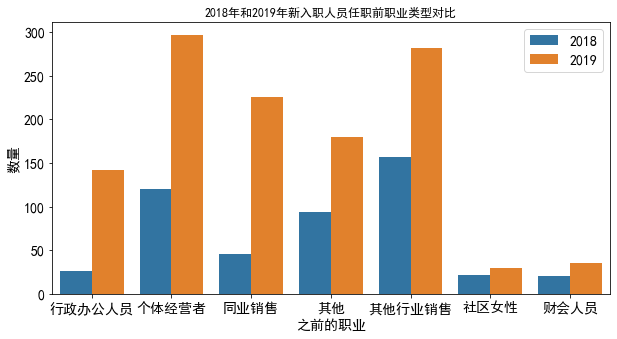

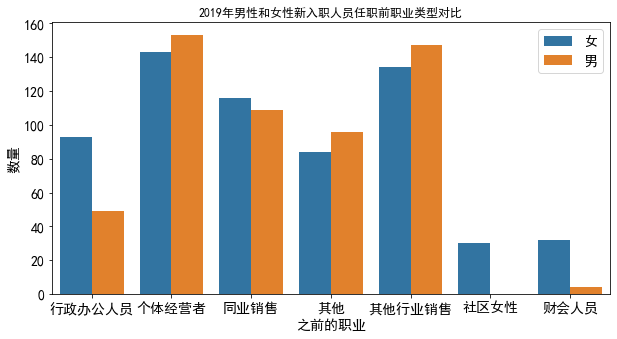

In [601]:
all_data.groupby('occupation').occupation.count()
#发现异常，处理异常项
def get_string(string):
    if string == '个体经营者、其他行业销售':
        return '个体经营者'
    elif string == '同业销售、个体经营者':
        return '个体经营者'
    else:
        return string

#柱状图和饼图

all_data['occupation'] = all_data['occupation'].apply(get_string)
# all_data.groupby('occupation').occupation.count().sort_values().plot.barh(figsize = (10,5),ax = ax1)
# plt.xlabel('数量', fontsize = 14)
# plt.ylabel('之前从事的职业', fontsize = 14)

# all_data.groupby('occupation').occupation.count().sort_values().plot.pie(figsize = (10,5),ax = ax2)
# plt.xlabel('数量', fontsize = 14)
# plt.ylabel('之前从事的职业', fontsize = 14)
# plt.yticks(fontsize = 14, ax = [ax1, ax2])
# plt.xticks(fontsize = 14, ax = [ax1, ax2])
plt.figure(figsize = (10,5))
sns.countplot(x = 'occupation', hue = 'label', data = all_data)
plt.xlabel('之前的职业', fontsize = 14)
plt.ylabel('数量', fontsize = 14)
plt.yticks(fontsize = 14)
plt.xticks(fontsize = 14)
plt.legend(fontsize = 14)
plt.title('2018年和2019年新入职人员任职前职业类型对比')

plt.figure(figsize = (10,5))
sns.countplot(x = 'occupation', hue = 'gender', data = all_data[all_data['label'] == 2019])
plt.xlabel('之前的职业', fontsize = 14)
plt.ylabel('数量', fontsize = 14)
plt.yticks(fontsize = 14)
plt.xticks(fontsize = 14)
plt.legend(fontsize = 14)
plt.title('2019年男性和女性新入职人员任职前职业类型对比')


Text(0.5, 1.0, '2018年新入职员工学历')

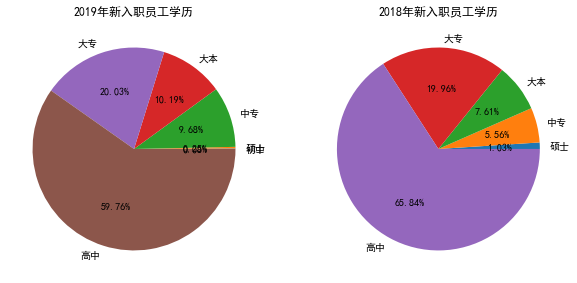

In [474]:
temp1 = all_data[all_data['label'] == 2019].groupby('education').education.count().sort_values()
temp2 = all_data[all_data['label'] == 2018].groupby('education').education.count().sort_values()

# 画饼图
fig, axes = plt.subplots(1,2, figsize = (10,10))
labels1 = ['初中','硕士','中专','大本','大专','高中']
labels2 = ['硕士','中专','大本','大专','高中']
axes[0].pie(temp1,labels = labels1,autopct = '%3.2f%%')
axes[1].pie(temp2,labels = labels2,autopct = '%3.2f%%')
axes[0].set_title('2019年新入职员工学历')
axes[1].set_title('2018年新入职员工学历')

Text(0.5, 1.0, '2018年新入职员工婚姻状态')

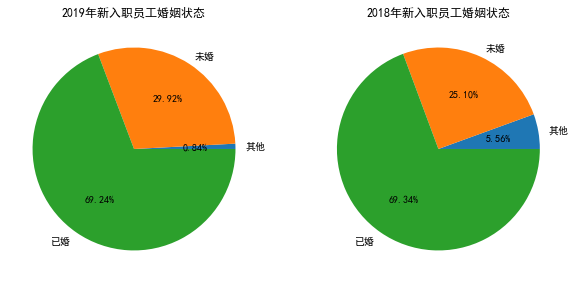

In [473]:
temp1 = all_data[all_data['label'] == 2019].groupby('marriage').marriage.count().sort_values()
temp2 = all_data[all_data['label'] == 2018].groupby('marriage').marriage.count().sort_values()


# 画饼图
fig, axes = plt.subplots(1,2, figsize = (10,10))
labels = ['其他','未婚','已婚']
axes[0].pie(temp1,labels = labels,autopct = '%3.2f%%')
axes[1].pie(temp2,labels = labels,autopct = '%3.2f%%')
axes[0].set_title('2019年新入职员工婚姻状态')
axes[1].set_title('2018年新入职员工婚姻状态')

## 新入职的员工中，优质员工的比例

In [523]:
# 2019年新招聘的员工中，学历为大专或大本以上的45岁以下的有销售经验的女员工占总女员工的比例
print('2019女:\t')
print(
    len(all_data[(all_data['education'].isin(['大专','大本','硕士'])) & (all_data['gender']=='女') 
             & (all_data['label']==2019)])/len(all_data[(all_data['gender']=='女') & (all_data['label']==2019)])
     )
# 2019年新招聘的员工中，学历为大专或大本以上的45岁以下的有销售经验的男员工占总男员工的比例
print('2019男:\t')
print(
    len(all_data[(all_data['education'].isin(['大专','大本','硕士'])) & (all_data['gender']=='男') 
             & (all_data['label']==2019)])/len(all_data[(all_data['gender']=='男') & (all_data['label']==2019)])
     )

# 2018年新招聘的员工中，学历为大专或大本以上的45岁以下的有销售经验的女员工占总女员工的比例
print('2018女:\t')
print(
    len(all_data[(all_data['education'].isin(['大专','大本','硕士'])) & (all_data['gender']=='女') 
             & (all_data['label']==2018)])/len(all_data[(all_data['gender']=='女') & (all_data['label']==2018)])
     )
# 2018年新招聘的员工中，学历为大专或大本以上的45岁以下的有销售经验的男员工占总男员工的比例
print('2018男:\t')
print(
    len(all_data[(all_data['education'].isin(['大专','大本','硕士'])) & (all_data['gender']=='男') 
             & (all_data['label']==2018)])/len(all_data[(all_data['gender']=='男') & (all_data['label']==2018)])
     )

2019女:	
0.3022151898734177
2019男:	
0.3064516129032258
2018女:	
0.3079710144927536
2018男:	
0.2571428571428571


# 新入职的员工中，再深居住的时间的比例

Text(0.5, 1.0, '2018年新入职员工在深居住时间')

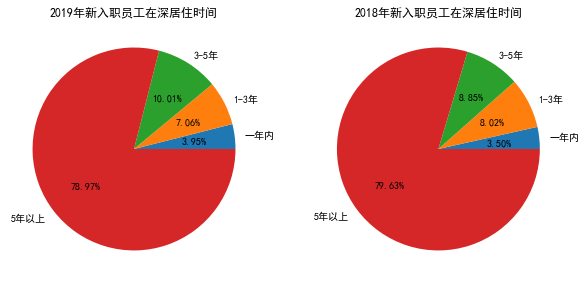

In [529]:
temp1 = all_data[all_data['label'] == 2019].groupby('residency_time').residency_time.count().sort_values()
temp2 = all_data[all_data['label'] == 2018].groupby('residency_time').residency_time.count().sort_values()


# 画饼图
fig, axes = plt.subplots(1,2, figsize = (10,10))
labels = ['一年内','1-3年','3-5年','5年以上']
axes[0].pie(temp1,labels = labels,autopct = '%3.2f%%')
axes[1].pie(temp2,labels = labels,autopct = '%3.2f%%')
axes[0].set_title('2019年新入职员工在深居住时间')
axes[1].set_title('2018年新入职员工在深居住时间')

## 新入职人员任职前职业类型对比

In [826]:
occupation = list(np.unique(all_data[all_data['label']==2019].occupation.values))
print(occupation) 

# 分男女
num2019_male = list(all_data[(all_data['label'] == 2019) & ( all_data['gender']== '男')].groupby('occupation').occupation.count())
print(num2019_male)
num2019_male.insert(4,0)
print('\t2019年男性各职业数量:',num2019_male)

num2019_female = list(all_data[(all_data['label'] == 2019) & ( all_data['gender']== '女')].groupby('occupation').occupation.count())
print('\t2019年女性各职业数量:',num2019_female)


num2019 = list(all_data[all_data['label']==2019].groupby('occupation').occupation.count())
print('\t2019年各职业数量:',num2019)

num2019_male_ratio = [num2019_male[i]/num2019[i] for i in range(len(num2019))]
num2019_male_ratio = list(np.round(num2019_male_ratio,2))
print('\t2019年男性新职员占比:',num2019_male_ratio)

num2019_female_ratio = [num2019_female[i]/num2019[i] for i in range(len(num2019))]
num2019_female_ratio = list(np.round(num2019_female_ratio,2))
print('\t2019年女性新职员占比:', num2019_female_ratio)


key = ['value','percent']
temp1 = []
for i in range(len(num2019)):
    temp1.append([num2019_male[i], num2019_male_ratio[i]])


temp2= []
for i in range(len(num2019)):
    temp2.append([num2019_female[i], num2019_female_ratio[i]])

# 用zip函数可以把[a,b],[c,d]转换成[(a,c),(b,d)]格式
# 用dict函数可以把[(a,c),(b,d)]转换成{'a':'c', 'b':'d'}格式
male_dict_list_2019 = []
for i in range(len(temp1)):
    male_dict_list_2019.append(dict(zip(key,temp1[i])))
print('男比例:',male_dict_list_2019)

female_dict_list_2019 = []
for i in range(len(temp2)):
    female_dict_list_2019.append(dict(zip(key,temp2[i])))
print('女比例:', female_dict_list_2019)

# def new_staff_former_occupation() -> Bar:
#     x = occupation
#     bar = (
#         Bar()
#         .add_xaxis(x)
#         .add_yaxis('男', num2019_male)
#         .add_yaxis('女', num2019_female)
#         .set_global_opts(title_opts=opts.TitleOpts(title="Overlap-line+scatter"))
#     )
#     line = (
#         Line()
#         .add_xaxis(x)
#         .add_yaxis('男', num2019_male)
#         .add_yaxis('女', num2019_female)
#         .set_series_opts(label_opts=opts.LabelOpts(is_show=False))
#     )
#     bar.overlap(line)
#     return bar
# new_staff_former_occupation().render_notebook()




['个体经营者', '其他', '其他行业销售', '同业销售', '社区女性', '行政办公人员', '财会人员']
[153, 96, 147, 109, 49, 4]
	2019年男性各职业数量: [153, 96, 147, 109, 0, 49, 4]
	2019年女性各职业数量: [143, 84, 134, 116, 30, 93, 32]
	2019年各职业数量: [296, 180, 281, 225, 30, 142, 36]
	2019年男性新职员占比: [0.52, 0.53, 0.52, 0.48, 0.0, 0.35, 0.11]
	2019年女性新职员占比: [0.48, 0.47, 0.48, 0.52, 1.0, 0.65, 0.89]
男比例: [{'value': 153, 'percent': 0.52}, {'value': 96, 'percent': 0.53}, {'value': 147, 'percent': 0.52}, {'value': 109, 'percent': 0.48}, {'value': 0, 'percent': 0.0}, {'value': 49, 'percent': 0.35}, {'value': 4, 'percent': 0.11}]
女比例: [{'value': 143, 'percent': 0.48}, {'value': 84, 'percent': 0.47}, {'value': 134, 'percent': 0.48}, {'value': 116, 'percent': 0.52}, {'value': 30, 'percent': 1.0}, {'value': 93, 'percent': 0.65}, {'value': 32, 'percent': 0.89}]


In [768]:
num2018_male = list(all_data[(all_data['label'] == 2018) & ( all_data['gender']== '男')].groupby('occupation').occupation.count())
print(num2018_male)
num2018_male.insert(4,0)
print('\t2018年男性各职业数量:',num2018_male)

num2018_female = list(all_data[(all_data['label'] == 2018) & ( all_data['gender']== '女')].groupby('occupation').occupation.count())
print('\t2018年女性各职业数量:',num2018_female)


num2018 = list(all_data[all_data['label']==2018].groupby('occupation').occupation.count())
print('\t2018年各职业数量:',num2018)

num2018_male_ratio = [num2018_male[i]/num2018[i] for i in range(len(num2018))]
num2018_male_ratio = list(np.round(num2018_male_ratio,2))
print('\t2018年男性新职员占比:',num2018_male_ratio)

num2018_female_ratio = [num2018_female[i]/num2018[i] for i in range(len(num2018))]
num2018_female_ratio = list(np.round(num2018_female_ratio,2))
print('\t2018年女性新职员占比:', num2018_female_ratio)


key = ['value','percent']
temp1 = []
for i in range(len(num2018)):
    temp1.append([num2018_male[i], num2018_male_ratio[i]])
temp2= []
for i in range(len(num2018)):
    temp2.append([num2018_female[i], num2018_female_ratio[i]])
    
# 用zip函数可以把[a,b],[c,d]转换成[(a,c),(b,d)]格式
# 用dict函数可以把[(a,c),(b,d)]转换成{'a':'c', 'b':'d'}格式
male_dict_list_2018 = []
for i in range(len(temp1)):
    male_dict_list_2018.append(dict(zip(key,temp1[i])))
print('男比例:',male_dict_list_2018)

female_dict_list_2018 = []
for i in range(len(temp2)):
    female_dict_list_2018.append(dict(zip(key,temp2[i])))
print('女比例:', female_dict_list_2018)

[54, 51, 70, 27, 5, 3]
	2018年男性各职业数量: [54, 51, 70, 27, 0, 5, 3]
	2018年女性各职业数量: [66, 43, 87, 19, 22, 21, 18]
	2018年各职业数量: [120, 94, 157, 46, 22, 26, 21]
	2018年男性新职员占比: [0.45, 0.54, 0.45, 0.59, 0.0, 0.19, 0.14]
	2018年女性新职员占比: [0.55, 0.46, 0.55, 0.41, 1.0, 0.81, 0.86]
男比例: [{'value': 54, 'percent': 0.45}, {'value': 51, 'percent': 0.54}, {'value': 70, 'percent': 0.45}, {'value': 27, 'percent': 0.59}, {'value': 0, 'percent': 0.0}, {'value': 5, 'percent': 0.19}, {'value': 3, 'percent': 0.14}]
女比例: [{'value': 66, 'percent': 0.55}, {'value': 43, 'percent': 0.46}, {'value': 87, 'percent': 0.55}, {'value': 19, 'percent': 0.41}, {'value': 22, 'percent': 1.0}, {'value': 21, 'percent': 0.81}, {'value': 18, 'percent': 0.86}]


In [827]:
def new_staff_former_occupation_ratio() -> Bar:
    bar = (
        Bar(init_opts = opts.InitOpts(width = "900px",height='500px'))#init_opts=opts.InitOpts(theme=ThemeType.LIGHT))
        .add_xaxis(occupation)
        .add_yaxis('',male_dict_list_2019, stack = 'stack1')
        .add_yaxis('2019年新入职女员工比重',female_dict_list_2019, stack = 'stack1')
        .add_yaxis('',male_dict_list_2018, stack = 'stack2')
        .add_yaxis('2018年新入职女员工比重',female_dict_list_2018, stack = 'stack2')
        .set_series_opts(label_opts = opts.LabelOpts(
            position='top',
            formatter = JsCode(
                "function(x){return Number(x.data.percent * 100).toFixed() + '%';}"
            )
        )
        )
#         .set_global_opts(title_opts=opts.TitleOpts(title="2018年和2019年新增员工之前从事的职业统计"))
    )
        
    line = (
        Line()
        .add_xaxis(occupation)
        .add_yaxis('2019年新入职女员工比重', num2019)
        .add_yaxis('2018年新入职女员工比重', num2018)
        .set_series_opts(label_opts=opts.LabelOpts(is_show=False))
    )
    
    bar.overlap(line)
    return bar

new_staff_former_occupation_ratio().render_notebook()


In [834]:
def new_staff_former_occupation_ratio() -> Bar:
    bar = (
        Bar(init_opts = opts.InitOpts(width = "900px",height='500px'))#init_opts=opts.InitOpts(theme=ThemeType.LIGHT))
        .add_xaxis(occupation)
        .add_yaxis('2019年新入职女员工比重',num2019_female_ratio)
        .add_yaxis('2018年新入职女员工比重',num2018_female_ratio)
        .set_global_opts(title_opts = opts.TitleOpts(title = '新增女员工的前职业比重'))
        )
        
        
    line = (
        Line()
        .add_xaxis(occupation)
        .add_yaxis('2019年新入职女员工比重', num2019_female_ratio)
        .add_yaxis('2018年新入职女员工比重', num2018_female_ratio)
        .set_series_opts(label_opts=opts.LabelOpts(is_show=False))
    )
    
    bar.overlap(line)
    return bar

new_staff_former_occupation_ratio().render_notebook()

In [837]:
def new_staff_former_occupation() -> Bar:
    bar = (
        Bar(init_opts = opts.InitOpts(width = "900px",height='500px'))#init_opts=opts.InitOpts(theme=ThemeType.LIGHT))
        .add_xaxis(occupation)
        .add_yaxis('2019年新入职员工前职业',num2019)
        .add_yaxis('2018年新入职员工前职业',num2018)
        .set_global_opts(title_opts = opts.TitleOpts(title = '新增员工的前职业'))
        )
        
        
    line = (
        Line()
        .add_xaxis(occupation)
        .add_yaxis('2019年新入职员工前职业', num2019)
        .add_yaxis('2018年新入职员工前职业', num2018)
        .set_series_opts(label_opts=opts.LabelOpts(is_show=False))
    )
    
    bar.overlap(line)
    return bar

new_staff_former_occupation().render_notebook()

In [ ]:
num2019_male = list(all_data[(all_data['label'] == 2019) & ( all_data['gender']== '男')].groupby('occupation').occupation.count())
print(num2019_male)
num2019_male.insert(4,0)
print('\t2019年男性各职业数量:',num2019_male)

num2019_female = list(all_data[(all_data['label'] == 2019) & ( all_data['gender']== '女')].groupby('occupation').occupation.count())
print('\t2019年女性各职业数量:',num2019_female)


num2019 = list(all_data[all_data['label']==2019].groupby('occupation').occupation.count())
print('\t2019年各职业数量:',num2019)

num2019_male_ratio = [num2019_male[i]/num2019[i] for i in range(len(num2019))]
num2019_male_ratio = list(np.round(num2019_male_ratio,2))
print('\t2019年男性新职员占比:',num2019_male_ratio)

num2019_female_ratio = [num2019_female[i]/num2019[i] for i in range(len(num2019))]
num2019_female_ratio = list(np.round(num2019_female_ratio,2))
print('\t2019年女性新职员占比:', num2019_female_ratio)


key = ['value','percent']
temp1 = []
for i in range(len(num2019)):
    temp1.append([num2019_male[i], num2019_male_ratio[i]])


temp2= []
for i in range(len(num2019)):
    temp2.append([num2019_female[i], num2019_female_ratio[i]])

In [949]:
# 分年份
num2019 = list(all_data[(all_data['label'] == 2019)].groupby('occupation').occupation.count()[0:7])
print(num2019)

num2018 = list(all_data[(all_data['label'] == 2018)].groupby('occupation').occupation.count()[0:7])
print(num2018)


def new_staff_former_occupation() -> Bar:
    x = occupation
    bar = (
        Bar()
        .add_xaxis(x)
        .add_yaxis('2019', num2019)
        .add_yaxis('2018', num2018)
        .set_global_opts(title_opts=opts.TitleOpts(title="2018年和2019年新增员工之前从事的职业统计"))
    )
    line = (
        Line()
        .add_xaxis(x)
        .add_yaxis('2019', num2019)
        .add_yaxis('2018', num2018)
        .set_series_opts(label_opts=opts.LabelOpts(is_show=False))
    )
    bar.overlap(line)
    return bar
new_staff_former_occupation().render_notebook()


age2019 = list(all_data[all_data['label'] == 2019].groupby('age_range').age_range.count())
age2018 = list(all_data[all_data['label'] == 2018].groupby('age_range').age_range.count())
all_data[all_data['label'] == 2019].groupby('age_range').age_range.count()
age_range = ['25-30岁','31-45岁','45岁以上','不足25岁']
def new_staff_age_range() -> Bar:
    x = age_range
    bar = (
    Bar()
    .add_xaxis(x)
    .add_yaxis('2019', age2019)
    .add_yaxis('2018', age2018)
    .set_global_opts(title_opts = opts.TitleOpts(title = '2018年和2019年新增员工年龄分布'))
    )
    
    line = (
    Line()
    .add_xaxis(x)
    .add_yaxis('2019', age2019)
    .add_yaxis('2018', age2018)
    .set_series_opts(label_opts=opts.LabelOpts(is_show=False))
    )
    bar.overlap(line)
    return bar
new_staff_age_range().render_notebook()

[296, 180, 281, 225, 30, 142, 36]
[120, 94, 157, 46, 22, 26, 21]
